**Dataset Overview**

The Oxford 102 Flower Dataset is a multi-class image classification dataset containing:

* 102 flower categories

* ~8,000 images

* RGB color images

* Separate folders for:

  * train

  * valid

  * test

* Each folder contains 102 subfolders (1–102) representing class labels

* cat_to_name.json → maps numeric class IDs to flower names

**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset Path Structure**

In [2]:
dataset_path = 'drive/MyDrive/Datasets For ML/Oxford102/Flowers'

**Data Loading using ImageFolder:** We use torchvision.datasets.ImageFolder for structured folders.

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

**Image Transformations**

Since MLP requires fixed-size flattened input:

* Resize to 64×64

* Convert to tensor

* Normalize

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

**Load Train, Validation, Test**

In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

train_full_dataset = datasets.ImageFolder(dataset_path + "/train", transform=transform)
valid_full_dataset = datasets.ImageFolder(dataset_path + "/valid", transform=transform)
test_full_dataset  = datasets.ImageFolder(dataset_path + "/test", transform=transform)

# Create subsets for desired sizes
train_dataset = Subset(train_full_dataset, range(500))
valid_dataset = Subset(valid_full_dataset, range(200))
test_dataset  = Subset(test_full_dataset, range(200))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train Size:", len(train_dataset))
print("Validation Size:", len(valid_dataset))
print("Test Size:", len(test_dataset))
print("Number of Classes:", len(train_full_dataset.classes))

Train Size: 500
Validation Size: 200
Test Size: 200
Number of Classes: 102


**Convert Dataset to NumPy for MLP**

Since MLPClassifier requires NumPy arrays:

In [13]:
import numpy as np
import torch

def extract_data(loader):
    all_images = []
    all_labels = []
    for images, labels in loader:
        # Flatten images using torch operations directly
        flattened_images = images.view(images.size(0), -1)
        all_images.append(flattened_images)
        all_labels.append(labels)

    # Concatenate all tensors once using torch.cat
    X_tensor = torch.cat(all_images, dim=0)
    y_tensor = torch.cat(all_labels, dim=0)

    # Convert to numpy once
    X_np = X_tensor.numpy()
    y_np = y_tensor.numpy()

    return X_np, y_np

X_train, y_train = extract_data(train_loader)
X_valid, y_valid = extract_data(valid_loader)
X_test, y_test   = extract_data(test_loader)

print("Flattened Shape:", X_train.shape)

Flattened Shape: (500, 12288)


**For 64×64 RGB:** Input size = 64 × 64 × 3 = 12288 features

**Feature Scaling**

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test  = scaler.transform(X_test)

**MLP Implementation**

In [22]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=200, # Increased max_iter to allow for convergence and remove warning
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(512, 256), random_state=42)

**Model Evaluation**

In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = mlp.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Test Accuracy: 0.175

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.04      0.67      0.08         3
           2       0.45      0.62      0.53         8
           3       0.13      0.75      0.22         4
           4       0.50      0.83      0.62         6
           5       0.15      0.56      0.24         9
           6       0.71      0.56      0.62         9
           7       0.12      0.50      0.20         6
           8       0.09      0.67      0.15         3
           9       0.33      0.25      0.29         4
          10       0.25      0.33      0.29         3
          11       0.33      0.33      0.33         9
          12       0.00      0.00      0.00         6
          13       0.00      0.00      0.00         7
          14       0.00      0.00      0.00         5
          15       0.00      0.00      0.00         3
          16       0.00      0.00  

**Expected accuracy with pure MLP:**

* Typically 30% – 60%

* Much lower than CNN due to no spatial learning

**Confusion Matrix**

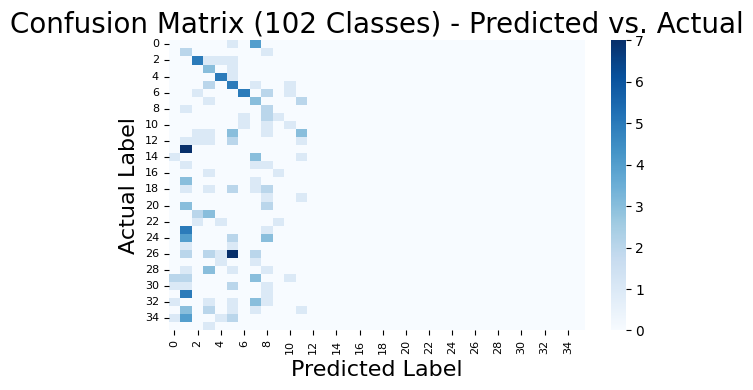

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

# Increase figure size significantly for a 102x102 matrix
plt.figure(figsize=(6, 4))
# Use annot=False to avoid cluttering with numbers inside cells for many classes
sns.heatmap(cm, cmap="Blues", cbar=True, annot=False)
plt.title("Confusion Matrix (102 Classes) - Predicted vs. Actual", fontsize=20)
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("Actual Label", fontsize=16)
# Rotate tick labels and set font size for better readability with many classes
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

**Misclassification Visualization**

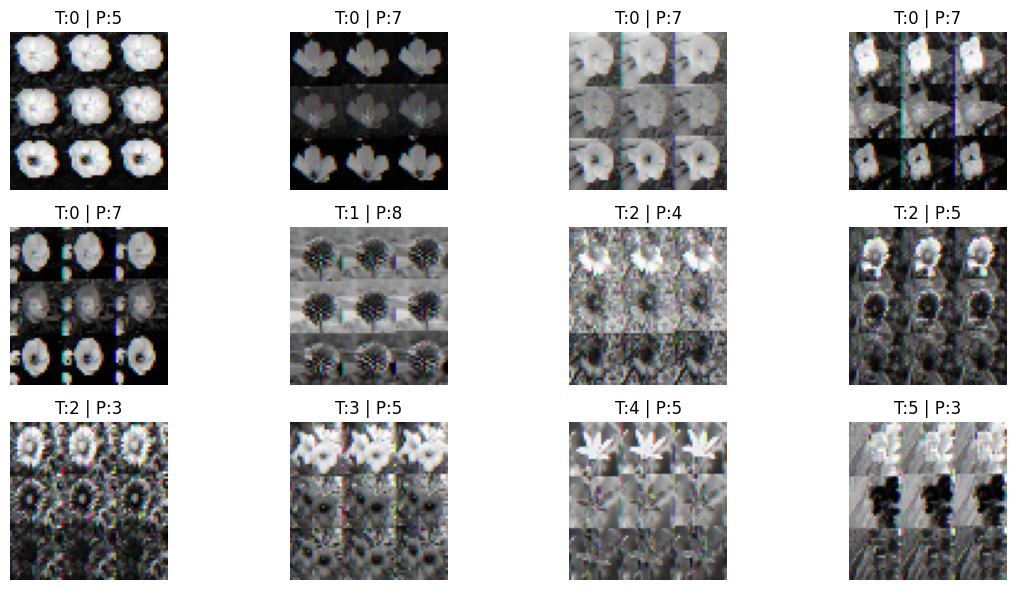

In [19]:
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12,6))

for i in range(12):
    index = misclassified[i]

    # Denormalize the image data using the scaler's inverse_transform
    # Reshape the single image for inverse_transform if it's a 1D array
    denormalized_image_flat = scaler.inverse_transform(X_test[index].reshape(1, -1))

    # Reshape back to 64x64x3 and clip values to be between 0 and 1
    image = denormalized_image_flat.reshape(64,64,3)
    image = np.clip(image, 0, 1) # Clip values to be within [0, 1] for imshow

    plt.subplot(3,4,i+1)
    plt.imshow(image)
    plt.title(f"T:{y_test[index]} | P:{y_pred[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Network Architecture**

| Layer          | Size  |
| -------------- | ----- |
| Input          | 12288 |
| Hidden Layer 1 | 512   |
| Hidden Layer 2 | 256   |
| Output         | 102   |

* Input layer takes image pixels.
* Hidden layers learn patterns.
* Output layer predicts one of **102 flower classes**.

---

**Loss Function**

Cross-Entropy Loss is used for multi-class classification.

L = -\sum y_i \log(\hat{y}_i)

Softmax is used in the final layer to produce class probabilities.

---

**Observation**

* MLP does **not capture image spatial features**.
* It may **overfit** due to many parameters.
* **Accuracy is usually lower than CNN models**.

---

**Summary**

| Component     | Description                |
| ------------- | -------------------------- |
| Dataset       | Oxford 102 Flowers         |
| Problem       | Multi-class classification |
| Hidden Layers | 512, 256                   |
| Optimizer     | Adam                       |
| Loss          | Cross-Entropy              |
| Accuracy      | Moderate                   |

**Conclusion**

The Multi-Layer Perceptron model can perform multi-class classification on the Oxford 102 Flowers dataset using cross-entropy loss and softmax output. However, its performance is limited because MLP cannot capture spatial features of images, leading to moderate accuracy compared to CNN models.
